# Football Match Result Prediction
### Predicting home_win / draw / away_win using in-game events

**Dataset:** Wyscout event data — England, Spain, Italy, Germany, France  
**Approach:** Engineer features from events up to a certain match minute, then train several classifiers and compare them across different cutoff times.  
**Note:** World Cup and European Championship matches are excluded because they involve national teams and different dynamics compared to club football leagues.


## 1. Imports and Setup

In [1]:
# Standard library
import json
import math
import os
import warnings
from collections import defaultdict
from pathlib import Path

# Data
import numpy as np
import pandas as pd

# Visualization — %matplotlib inline makes plots appear in the notebook output
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# XGBoost (optional but recommended)
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print("XGBoost loaded successfully.")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost not found — will run without it.")

import joblib

warnings.filterwarnings("ignore", category=FutureWarning)
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib-cache"))

RANDOM_STATE = 42
print("All imports done.")

XGBoost loaded successfully.
All imports done.


## 2. Configuration
Change these values to adjust the experiment.

In [2]:
# Paths
DATA_DIR   = Path("Data set")
OUTPUT_DIR = Path("artifacts")

# Only include club league competitions — World Cup and Euro Championship excluded
# because national-team tournaments work differently (squad selection, short formats, etc.)
COMPETITIONS = {"England", "Spain", "Italy", "Germany", "France"}

# How many minutes of match data to use as features (we test multiple)
CUTOFF_MINUTES = [45.0, 55.0, 65.0, 75.0, 80.0]

# 20% of matches held out for final testing
TEST_SIZE = 0.20

# 3-fold cross-validation on training data
CV_FOLDS = 3

# Chronological split — more realistic than random (we predict future games)
SPLIT = "chronological"

# Include team IDs as features (helps the model learn team strength)
INCLUDE_TEAM_IDS = True

# Permutation importance repeats (higher = more stable estimates, but slower)
PERMUTATION_REPEATS = 5

# Make output folders
for folder in [OUTPUT_DIR, OUTPUT_DIR/"figures", OUTPUT_DIR/"tables", OUTPUT_DIR/"models"]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Using competitions: {sorted(COMPETITIONS)}")
print(f"Cutoffs to test: {CUTOFF_MINUTES}")

Using competitions: ['England', 'France', 'Germany', 'Italy', 'Spain']
Cutoffs to test: [45.0, 55.0, 65.0, 75.0, 80.0]


## 3. Load Match Metadata
Parse match files to get home/away teams, scores, and the final result label.

In [3]:
# Helper: safely convert to int / float without crashing
def to_int(val, default=None):
    try:
        return int(val) if val not in (None, "") else default
    except (TypeError, ValueError):
        return default

def to_float(val, default=0.0):
    try:
        return float(val) if val not in (None, "") else default
    except (TypeError, ValueError):
        return default

# Load team names so we can show readable names instead of IDs
team_names = {}
teams_path = DATA_DIR / "teams.json"
if teams_path.exists():
    with teams_path.open(encoding="utf-8") as f:
        for t in json.load(f):
            tid = to_int(t.get("wyId"))
            if tid:
                team_names[tid] = t.get("officialName") or t.get("name") or str(tid)

print(f"Loaded {len(team_names)} team names.")

# Parse all match files and collect one row per match
match_rows = []

for path in sorted((DATA_DIR / "matches").glob("matches_*.json")):
    competition = path.stem.replace("matches_", "")
    if competition not in COMPETITIONS:
        continue  # skip World Cup, Euro Championship, etc.

    with path.open(encoding="utf-8") as f:
        matches = json.load(f)

    for m in matches:
        if m.get("status") and m.get("status") != "Played":
            continue

        # Find home and away team data
        home_data = next((v for v in (m.get("teamsData") or {}).values() if v.get("side") == "home"), None)
        away_data = next((v for v in (m.get("teamsData") or {}).values() if v.get("side") == "away"), None)
        if home_data is None or away_data is None:
            continue

        home_id = to_int(home_data.get("teamId"))
        away_id = to_int(away_data.get("teamId"))
        if home_id is None or away_id is None:
            continue

        home_score = to_int(home_data.get("score"), 0)
        away_score = to_int(away_data.get("score"), 0)
        result = "home_win" if home_score > away_score else ("away_win" if home_score < away_score else "draw")

        # Grab lineup player IDs for player-profile features later
        home_lineup = [to_int(p.get("playerId")) for p in (home_data.get("formation") or {}).get("lineup", []) if isinstance(p, dict)]
        away_lineup = [to_int(p.get("playerId")) for p in (away_data.get("formation") or {}).get("lineup", []) if isinstance(p, dict)]
        home_bench  = [to_int(p.get("playerId")) for p in (home_data.get("formation") or {}).get("bench",  []) if isinstance(p, dict)]
        away_bench  = [to_int(p.get("playerId")) for p in (away_data.get("formation") or {}).get("bench",  []) if isinstance(p, dict)]

        # Get main referee ID
        ref_id = None
        for ref in (m.get("referees") or []):
            if str(ref.get("role", "")).lower() == "referee":
                ref_id = to_int(ref.get("refereeId"))
                break
        if ref_id is None and m.get("referees"):
            ref_id = to_int(m["referees"][0].get("refereeId"))

        match_rows.append({
            "match_id":       to_int(m.get("wyId")),
            "competition":    competition,
            "season_id":      to_int(m.get("seasonId")),
            "gameweek":       to_int(m.get("gameweek"), 0),
            "dateutc":        pd.to_datetime(m.get("dateutc"), errors="coerce", utc=True),
            "home_team_id":   str(home_id),
            "away_team_id":   str(away_id),
            "home_team_name": team_names.get(home_id, str(home_id)),
            "away_team_name": team_names.get(away_id, str(away_id)),
            "home_score":     home_score,
            "away_score":     away_score,
            "total_goals":    home_score + away_score,
            "goal_diff_final":home_score - away_score,
            "target":         result,
            "main_referee_id": str(ref_id) if ref_id else "unknown",
            "home_lineup_ids": [x for x in home_lineup if x],
            "away_lineup_ids": [x for x in away_lineup if x],
            "home_bench_ids":  [x for x in home_bench  if x],
            "away_bench_ids":  [x for x in away_bench  if x],
        })

matches_df = (
    pd.DataFrame(match_rows)
    .drop_duplicates(subset=["match_id"])
    .sort_values("dateutc")
    .reset_index(drop=True)
)

print(f"Loaded {len(matches_df):,} played matches from {matches_df['competition'].nunique()} competitions.")
print(matches_df["competition"].value_counts().to_string())
print("\nResult distribution:")
print(matches_df["target"].value_counts().to_string())

Loaded 142 team names.
Loaded 1,826 played matches from 5 competitions.
competition
France     380
England    380
Spain      380
Italy      380
Germany    306

Result distribution:
target
home_win    828
away_win    551
draw        447


## 4. Team Form Features
For each match, calculate each team's historical stats (points per game, goals, recent form) using only data from matches played *before* this one. This avoids data leakage.

In [4]:
# Points earned in a match (3 for win, 1 for draw, 0 for loss)
def get_points(result, side):
    if result == "draw": return 1
    if side == "home":   return 3 if result == "home_win" else 0
    return 3 if result == "away_win" else 0

RECENT_WINDOW = 5  # look at last 5 games for recent form

# We iterate matches in chronological order and snapshot stats BEFORE updating them
# so we never use future information
team_history = defaultdict(lambda: {"n": 0, "pts": 0, "gf": 0, "ga": 0, "recent": []})
team_form_rows = []

for row in matches_df.sort_values("dateutc").itertuples(index=False):
    h, a = str(row.home_team_id), str(row.away_team_id)
    
    form_row = {"match_id": int(row.match_id)}
    for prefix, team_id in [("home", h), ("away", a)]:
        s = team_history[team_id]
        n = s["n"]
        recent = s["recent"][-RECENT_WINDOW:]
        form_row[f"{prefix}_prior_matches"]           = float(n)
        form_row[f"{prefix}_prior_pts_per_game"]      = s["pts"] / n if n else 0.0
        form_row[f"{prefix}_prior_gd_per_game"]       = (s["gf"] - s["ga"]) / n if n else 0.0
        form_row[f"{prefix}_prior_gf_per_game"]       = s["gf"] / n if n else 0.0
        form_row[f"{prefix}_prior_ga_per_game"]       = s["ga"] / n if n else 0.0
        form_row[f"{prefix}_recent_pts_per_game"]     = sum(recent) / len(recent) if recent else 0.0

    # diff features
    for key in ["prior_pts_per_game", "prior_gd_per_game", "prior_gf_per_game", "recent_pts_per_game"]:
        form_row[f"diff_{key}"] = form_row[f"home_{key}"] - form_row[f"away_{key}"]
    
    team_form_rows.append(form_row)

    # Update stats after recording the snapshot
    for prefix, team_id, my_score, opp_score in [
        ("home", h, row.home_score, row.away_score),
        ("away", a, row.away_score, row.home_score),
    ]:
        pts = get_points(row.target, prefix)
        team_history[team_id]["n"]   += 1
        team_history[team_id]["pts"] += pts
        team_history[team_id]["gf"]  += int(my_score)
        team_history[team_id]["ga"]  += int(opp_score)
        team_history[team_id]["recent"].append(pts)

team_form_df = pd.DataFrame(team_form_rows)
print(f"Team form features: {team_form_df.shape[1] - 1} columns for {len(team_form_df)} matches")

Team form features: 16 columns for 1826 matches


## 5. Player Profile and PlayerRank Features
Use player physical attributes (height, age, foot) and their prior PlayerRank scores as pre-match indicators of squad quality.

In [5]:
# Load player profiles (height, weight, birthdate, preferred foot, role)
player_profiles = {}
players_path = DATA_DIR / "players.json"
if players_path.exists():
    with players_path.open(encoding="utf-8") as f:
        for p in json.load(f):
            pid = to_int(p.get("wyId"))
            if pid:
                player_profiles[pid] = p
print(f"Loaded profiles for {len(player_profiles):,} players.")

# Build a prior-PlayerRank lookup: (match_id, player_id) -> average rank from PREVIOUS matches
# This tells us how good a player has historically performed before this specific match
prior_rank_lookup = {}
global_rank_fallback = 0.0

rank_path = DATA_DIR / "playerank.json"
if rank_path.exists():
    try:
        with rank_path.open(encoding="utf-8") as f:
            rank_records = json.load(f)
        ranks_df = pd.DataFrame(rank_records)
        ranks_df["matchId"]        = ranks_df["matchId"].apply(to_int)
        ranks_df["playerId"]       = ranks_df["playerId"].apply(to_int)
        ranks_df["playerankScore"] = pd.to_numeric(ranks_df["playerankScore"], errors="coerce")
        ranks_df = ranks_df.dropna(subset=["matchId", "playerId", "playerankScore"])
        
        # Merge with match dates so we can sort chronologically
        ranks_df = ranks_df.merge(matches_df[["match_id", "dateutc"]], left_on="matchId", right_on="match_id", how="inner")
        ranks_df = ranks_df.sort_values(["playerId", "dateutc"])
        
        # For each row: prior mean = cumulative mean BEFORE this game
        ranks_df["cumcount"] = ranks_df.groupby("playerId").cumcount()
        ranks_df["cumsum"]   = ranks_df.groupby("playerId")["playerankScore"].cumsum() - ranks_df["playerankScore"]
        ranks_df["prior_rank"] = ranks_df["cumsum"] / ranks_df["cumcount"].replace(0, np.nan)
        
        global_rank_fallback = float(ranks_df["playerankScore"].mean())
        for r in ranks_df.itertuples(index=False):
            if pd.notna(r.prior_rank):
                prior_rank_lookup[(int(r.matchId), int(r.playerId))] = float(r.prior_rank)
        print(f"PlayerRank lookup built: {len(prior_rank_lookup):,} entries, global fallback = {global_rank_fallback:.3f}")
    except Exception as e:
        print(f"Could not load playerank.json: {e}")
else:
    print("playerank.json not found — skipping player rank features.")


def summarize_squad_rank(match_id, player_ids):
    """Average prior rank of a squad. Falls back to global mean if missing."""
    vals = [prior_rank_lookup.get((match_id, pid), global_rank_fallback) for pid in player_ids if pid]
    if not vals:
        return {"rank_mean": global_rank_fallback, "rank_max": global_rank_fallback}
    return {"rank_mean": float(np.mean(vals)), "rank_max": float(np.max(vals))}


def summarize_player_profiles(player_ids, match_date):
    """Average physical and demographic stats for a group of players."""
    heights, ages = [], []
    left = right = known = 0
    for pid in player_ids:
        p = player_profiles.get(int(pid) if pid else 0)
        if not p: continue
        known += 1
        h = to_float(p.get("height"), np.nan)
        if np.isfinite(h) and h > 0: heights.append(h)
        bd = pd.to_datetime(p.get("birthDate"), errors="coerce", utc=True)
        if pd.notna(bd) and pd.notna(match_date):
            ages.append((match_date - bd).days / 365.25)
        foot = str(p.get("foot") or "").lower()
        left  += int(foot == "left")
        right += int(foot == "right")
    denom = max(len(player_ids), 1)
    return {
        "profile_known_share": known / denom,
        "avg_height":          float(np.mean(heights)) if heights else 0.0,
        "avg_age":             float(np.mean(ages))    if ages    else 0.0,
        "left_foot_share":     left  / denom,
        "right_foot_share":    right / denom,
    }


# Build one row per match with squad rank and profile stats
player_context_rows = []
for row in matches_df.itertuples(index=False):
    mid = int(row.match_id)
    feature_row = {"match_id": mid}
    
    sides = {
        "home": list(row.home_lineup_ids) + list(row.home_bench_ids),
        "away": list(row.away_lineup_ids) + list(row.away_bench_ids),
    }
    summaries = {}
    for side, squad in sides.items():
        starters = getattr(row, f"{side}_lineup_ids")
        rank  = summarize_squad_rank(mid, starters)
        prof  = summarize_player_profiles(starters, row.dateutc)
        combined = {**{f"rank_{k}": v for k, v in rank.items()}, **prof}
        summaries[side] = combined
        for k, v in combined.items():
            feature_row[f"{side}_{k}"] = v
    
    for k in summaries["home"]:
        feature_row[f"diff_{k}"] = summaries["home"][k] - summaries["away"][k]
    player_context_rows.append(feature_row)

player_context_df = pd.DataFrame(player_context_rows)
print(f"Player context features: {player_context_df.shape[1] - 1} columns")

Loaded profiles for 3,603 players.
PlayerRank lookup built: 41,820 entries, global fallback = 0.007
Player context features: 21 columns


## 6. Event Feature Engineering
Read all event files once and accumulate stats per team per match for every cutoff minute at the same time. This saves a lot of time compared to reading the files once per cutoff.

In [6]:
# Period offsets: convert (period, seconds) into a continuous match minute
PERIOD_OFFSETS = {"1H": 0.0, "2H": 45.0, "E1": 90.0, "E2": 105.0, "P": 120.0}

# Tag IDs we care about (from the Wyscout tag dictionary)
GOAL_TAGS  = {101}          # goal scored
OWN_GOAL   = {102}
ON_TARGET  = set(range(1201, 1210)) | set(range(1217, 1224)) | {101}
POST_TAGS  = set(range(1217, 1224))


def get_minute(event):
    """Return the continuous match minute for an event, or None if invalid."""
    period = event.get("matchPeriod")
    if period not in PERIOD_OFFSETS: return None
    secs = to_float(event.get("eventSec"), np.nan)
    if not np.isfinite(secs) or secs < 0: return None
    return PERIOD_OFFSETS[period] + secs / 60.0


def get_position(event, idx, key):
    """Safely extract a position value (0-100) from event positions list."""
    positions = event.get("positions") or []
    if idx >= len(positions) or not isinstance(positions[idx], dict): return None
    v = to_float(positions[idx].get(key), np.nan)
    return v if (np.isfinite(v) and 0 <= v <= 100) else None


def xg_proxy(sx, sy, tags, subevent):
    """Rough xG estimate from shot location and context (no true xG labels available)."""
    if 101 in tags: return 0.85          # it went in
    if subevent == "penalty": return 0.76
    if sx is None or sy is None:
        base = 0.06
    else:
        dist = math.sqrt(((100.0 - sx) * 1.05)**2 + ((50.0 - sy) * 0.68)**2)
        centrality = max(0.0, 1.0 - abs(sy - 50.0) / 50.0)
        base = 1.0 / (1.0 + math.exp(-(1.8 - 0.085*dist + 0.65*centrality)))
    if 403 in tags:                base *= 0.75  # header
    if 2101 in tags:               base *= 0.55  # blocked
    if subevent == "free_kick_shot": base *= 0.65
    if tags & POST_TAGS:           base *= 0.90
    return float(np.clip(base, 0.01, 0.85))


def update_stats(stats, event):
    """Add features from a single event into a running stats dict for one team."""
    ev   = str(event.get("eventName") or "").strip().lower().replace(" ", "_")
    sub  = str(event.get("subEventName") or "").strip().lower().replace(" ", "_")
    tags = {to_int(t.get("id")) for t in event.get("tags", []) if isinstance(t, dict)}
    tags.discard(None)

    sx = get_position(event, 0, "x")
    sy = get_position(event, 0, "y")
    ex = get_position(event, 1, "x")
    ey = get_position(event, 1, "y")

    stats["events"] += 1

    # Location-based features
    if sx is not None and sy is not None:
        stats["sx_sum"] += sx
        stats["sx_n"]   += 1
        if sx >= 66:                                   stats["final_third"] += 1
        if sx >= 84 and 19 <= sy <= 81:                stats["penalty_area"] += 1
    if ex is not None and sx is not None:
        prog = ex - sx
        stats["prog_sum"] += prog
        stats["prog_n"]   += 1
        if prog >= 10: stats["progressive"] += 1
    if ex is not None and ey is not None:
        if ex >= 84 and 19 <= ey <= 81: stats["box_entries"] += 1

    # Passes
    if ev == "pass":
        stats["passes"] += 1
        if 1801 in tags: stats["acc_passes"] += 1
        if sub == "cross" and 1801 in tags: stats["acc_crosses"] += 1
        if sub == "cross": stats["crosses"] += 1
        if sub in ("smart_pass", "through_ball") or 901 in tags: stats["through_passes"] += 1

    # Shots
    elif ev == "shot":
        stats["shots"] += 1
        if 101 in tags: stats["goals"] += 1
        if tags & ON_TARGET: stats["shots_on_target"] += 1
        if 2101 in tags: stats["blocked_shots"] += 1
        stats["xg"] += xg_proxy(sx, sy, tags, sub)
        if sub == "penalty": stats["penalty_shots"] += 1

    # Duels
    elif ev == "duel":
        stats["duels"] += 1
        if 703 in tags: stats["duels_won"] += 1
        if 701 in tags: stats["duels_lost"] += 1

    # Fouls
    elif ev == "foul":
        stats["fouls"] += 1

    # Free kicks / corners
    elif ev == "free_kick":
        stats["free_kicks"] += 1
        if sub == "corner": stats["corners"] += 1
        if sub == "penalty": stats["penalties"] += 1

    # Cards
    if 1702 in tags: stats["yellow_cards"] += 1
    if 1701 in tags or 1703 in tags: stats["red_cards"] += 1
    if 102 in tags: stats["own_goals"] += 1
    if 2001 in tags: stats["dangerous_losses"] += 1
    if 1901 in tags: stats["counter_attacks"] += 1


# ── Main loop: read every event file once, bin events into per-cutoff accumulators ──
match_ids = set(matches_df["match_id"].astype(int))
valid_keys = set()  # (match_id, team_id_str)
for row in matches_df.itertuples(index=False):
    valid_keys.add((int(row.match_id), str(row.home_team_id)))
    valid_keys.add((int(row.match_id), str(row.away_team_id)))

cutoffs = sorted(CUTOFF_MINUTES)
# stats_by_cutoff[cutoff][(match_id, team_str)] = defaultdict(float)
stats_by_cutoff = {c: defaultdict(lambda: defaultdict(float)) for c in cutoffs}

seen_event_ids = set()
total_raw = total_kept = 0

for path in sorted((DATA_DIR / "events").glob("events_*.json")):
    competition = path.stem.replace("events_", "")
    if competition not in COMPETITIONS:
        continue  # skip World Cup and Euro events

    print(f"  Processing {competition}...", end=" ")
    with path.open(encoding="utf-8") as f:
        events = json.load(f)

    for ev in events:
        total_raw += 1
        eid = to_int(ev.get("id"))
        if eid:
            if eid in seen_event_ids: continue
            seen_event_ids.add(eid)

        mid  = to_int(ev.get("matchId"))
        if mid not in match_ids: continue

        minute = get_minute(ev)
        if minute is None: continue

        tid = to_int(ev.get("teamId"))
        key = (int(mid), str(tid))
        if key not in valid_keys: continue

        # Add this event to every cutoff bucket where it falls within the window
        for cutoff in cutoffs:
            if minute <= cutoff:
                update_stats(stats_by_cutoff[cutoff][key], ev)
                total_kept += 1

    print("done")

print(f"\nProcessed {total_raw:,} raw events. Kept (across all cutoffs): {total_kept:,}")

  Processing England... done
  Processing France... done
  Processing Germany... done
  Processing Italy... done
  Processing Spain... done

Processed 3,071,395 raw events. Kept (across all cutoffs): 10,729,254


## 7. Build Feature Matrix
Convert the raw per-team event counts into a match-level feature table. Each row is one match; features include home stats, away stats, and home-minus-away differences.

In [7]:
def safe_ratio(num, denom):
    return float(num / denom) if denom else 0.0


def finalize_team_stats(raw, cutoff):
    """Derive rate and ratio features from raw event counts for one team."""
    s = dict(raw)
    events  = s.get("events", 0)
    passes  = s.get("passes", 0)
    shots   = s.get("shots", 0)
    duels   = s.get("duels", 0)
    
    # Rate per minute
    s["events_per_min"]   = safe_ratio(events, cutoff)
    s["passes_per_min"]   = safe_ratio(passes, cutoff)
    s["shots_per_min"]    = safe_ratio(shots,  cutoff)
    
    # Efficiency ratios
    s["pass_accuracy"]        = safe_ratio(s.get("acc_passes", 0), passes)
    s["shot_on_target_rate"]  = safe_ratio(s.get("shots_on_target", 0), shots)
    s["goal_conversion"]      = safe_ratio(s.get("goals", 0), shots)
    s["xg_per_shot"]          = safe_ratio(s.get("xg", 0), shots)
    s["duel_win_rate"]         = safe_ratio(s.get("duels_won", 0), duels)
    s["duel_loss_rate"]        = safe_ratio(s.get("duels_lost", 0), duels)
    
    # Location / territory
    s["final_third_rate"]     = safe_ratio(s.get("final_third", 0), events)
    s["penalty_area_rate"]    = safe_ratio(s.get("penalty_area", 0), events)
    s["progressive_rate"]     = safe_ratio(s.get("progressive", 0), events)
    s["box_entry_rate"]       = safe_ratio(s.get("box_entries", 0), events)
    s["mean_start_x"]         = safe_ratio(s.get("sx_sum", 0), s.get("sx_n", 0))
    s["mean_progression"]     = safe_ratio(s.get("prog_sum", 0), s.get("prog_n", 0))
    s["dangerous_loss_rate"]  = safe_ratio(s.get("dangerous_losses", 0), events)
    s["counter_attack_rate"]  = safe_ratio(s.get("counter_attacks", 0), events)
    
    # Remove intermediate accumulator columns
    for k in ["sx_sum", "sx_n", "prog_sum", "prog_n"]:
        s.pop(k, None)
    return s


def build_match_features(matches_df, raw_stats, cutoff):
    """Join home and away team stats into one row per match."""
    # Pre-compute finalized stats for all teams in this cutoff
    finalized = {key: finalize_team_stats(val, cutoff) for key, val in raw_stats.items()}
    all_stat_keys = sorted({k for stats in finalized.values() for k in stats})

    rows = []
    for row in matches_df.itertuples(index=False):
        mid   = int(row.match_id)
        h_tid = str(row.home_team_id)
        a_tid = str(row.away_team_id)
        hs    = finalized.get((mid, h_tid), {})
        as_   = finalized.get((mid, a_tid), {})

        # Current score at cutoff minute
        h_goals = hs.get("goals", 0) + as_.get("own_goals", 0)
        a_goals = as_.get("goals", 0) + hs.get("own_goals", 0)

        h_ev = hs.get("events", 0)
        a_ev = as_.get("events", 0)
        h_pa = hs.get("passes", 0)
        a_pa = as_.get("passes", 0)

        feature_row = {
            "match_id":             mid,
            "dateutc":              row.dateutc,
            "competition":          row.competition,
            "home_team_id":         h_tid,
            "away_team_id":         a_tid,
            "home_team_name":       row.home_team_name,
            "away_team_name":       row.away_team_name,
            "home_score":           row.home_score,
            "away_score":           row.away_score,
            "total_goals":          row.total_goals,
            "goal_diff_final":      row.goal_diff_final,
            "target":               row.target,
            "cutoff_minute":        cutoff,
            # Live score at cutoff
            "home_current_goals":   h_goals,
            "away_current_goals":   a_goals,
            "current_goal_diff":    h_goals - a_goals,
            "abs_goal_diff":        abs(h_goals - a_goals),
            "is_draw_at_cutoff":    float(h_goals == a_goals),
            "home_leading":         float(h_goals > a_goals),
            "away_leading":         float(h_goals < a_goals),
            # Possession proxies
            "event_share_diff":     safe_ratio(h_ev - a_ev, h_ev + a_ev),
            "pass_share_diff":      safe_ratio(h_pa - a_pa, h_pa + a_pa),
        }

        # Home, away, and diff for every stat
        for k in all_stat_keys:
            hv = hs.get(k, 0.0)
            av = as_.get(k, 0.0)
            feature_row[f"home_{k}"] = hv
            feature_row[f"away_{k}"] = av
            feature_row[f"diff_{k}"] = hv - av

        rows.append(feature_row)

    return pd.DataFrame(rows).sort_values("dateutc").reset_index(drop=True)


# Build and attach context features for every cutoff
feature_dfs = {}
for cutoff in cutoffs:
    base_df = build_match_features(matches_df, stats_by_cutoff[cutoff], cutoff)
    # Attach team form
    df = base_df.merge(team_form_df, on="match_id", how="left")
    # Attach player features
    df = df.merge(player_context_df, on="match_id", how="left")
    # Fill any remaining nulls in numeric columns
    for col in df.select_dtypes(include=[np.number]).columns:
        df[col] = df[col].fillna(0.0)
    feature_dfs[cutoff] = df
    print(f"Cutoff {cutoff:g}: {df.shape[0]} matches × {df.shape[1]} columns")

# Save the 80-minute feature table as the main artifact
feature_dfs[80.0].to_csv(OUTPUT_DIR / "tables" / "engineered_match_features.csv", index=False)
print("\nSaved engineered_match_features.csv (80-min cutoff)")

Cutoff 45: 1826 matches × 191 columns
Cutoff 55: 1826 matches × 191 columns
Cutoff 65: 1826 matches × 191 columns
Cutoff 75: 1826 matches × 191 columns
Cutoff 80: 1826 matches × 191 columns

Saved engineered_match_features.csv (80-min cutoff)


## 8. Exploratory Data Analysis
Quick look at the data before modeling.

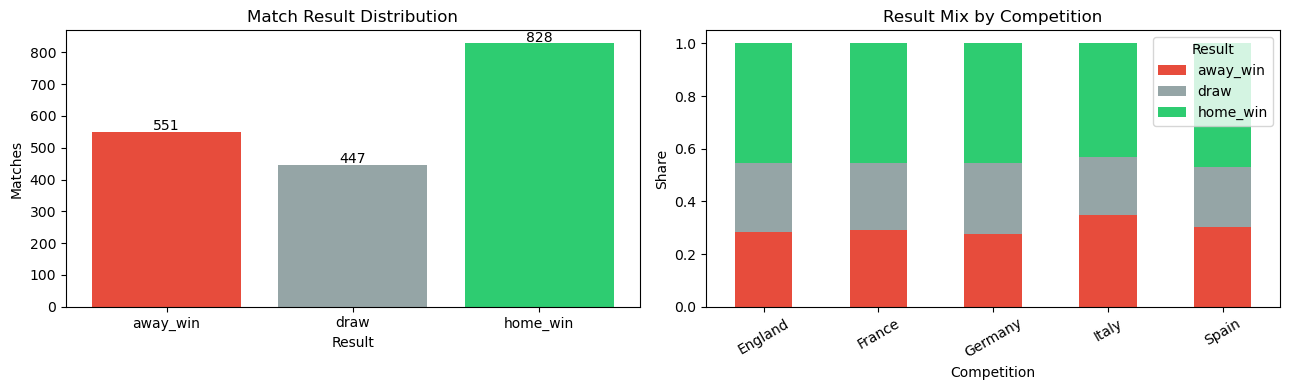

Top 15 features correlated with match result:


/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,abs_correlation
current_goal_diff,0.749
diff_goals,0.739
home_leading,0.709
away_leading,0.706
diff_goal_conversion,0.588
home_current_goals,0.558
away_current_goals,0.553
home_goals,0.552
away_goals,0.544
diff_shots_on_target,0.508


In [8]:
# Use the 80-minute feature table for EDA
eda_df = feature_dfs[80.0]

# -- 1. Target distribution --
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

order = ["away_win", "draw", "home_win"]
vc = eda_df["target"].value_counts()
axes[0].bar([o for o in order if o in vc.index], [vc[o] for o in order if o in vc.index],
            color=["#e74c3c", "#95a5a6", "#2ecc71"])
axes[0].set_title("Match Result Distribution")
axes[0].set_xlabel("Result")
axes[0].set_ylabel("Matches")
for i, (o) in enumerate([o for o in order if o in vc.index]):
    axes[0].text(i, vc[o] + 5, str(vc[o]), ha="center", fontsize=10)

# -- 2. Result mix by competition --
ct = pd.crosstab(eda_df["competition"], eda_df["target"], normalize="index")
ct[[c for c in order if c in ct.columns]].plot(kind="bar", stacked=True, ax=axes[1],
    color=["#e74c3c", "#95a5a6", "#2ecc71"])
axes[1].set_title("Result Mix by Competition")
axes[1].set_xlabel("Competition")
axes[1].set_ylabel("Share")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(title="Result", loc="upper right")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figures" / "eda_overview.png", dpi=150)
plt.show()

# -- 3. Quick correlation: which features correlate most with the target? --
numeric_cols = eda_df.select_dtypes(include=[np.number]).columns.tolist()
# Exclude outcome/meta columns from correlation analysis
meta = {"home_score", "away_score", "goal_diff_final", "total_goals", "cutoff_minute", "match_id"}
corr_cols = [c for c in numeric_cols if c not in meta]

target_num = eda_df["target"].map({"away_win": -1, "draw": 0, "home_win": 1})
correlations = eda_df[corr_cols].corrwith(target_num).abs().sort_values(ascending=False)

print("Top 15 features correlated with match result:")
display(correlations.head(15).rename("abs_correlation").to_frame().round(3))

# Save a summary table
eda_df["target"].value_counts().rename_axis("result").reset_index(name="count").to_csv(
    OUTPUT_DIR / "tables" / "target_distribution.csv", index=False)

## 9. Model Training and Evaluation
Train several classifiers and compare them. We use a chronological split so the test set is always later matches — this is more realistic than a random split.

In [9]:
# Columns we never feed into the model (they leak the outcome or are just IDs)
METADATA_COLS = {
    "match_id", "dateutc", "target",
    "home_score", "away_score", "goal_diff_final", "total_goals",
    "home_team_name", "away_team_name",
    "home_lineup_ids", "away_lineup_ids", "home_bench_ids", "away_bench_ids",
}

# Categorical columns that need one-hot encoding
CAT_COLS = ["competition"]
if INCLUDE_TEAM_IDS:
    CAT_COLS += ["home_team_id", "away_team_id"]
else:
    METADATA_COLS.update({"home_team_id", "away_team_id"})


def split_data(df, test_size=0.20, method="chronological"):
    """Split into train/test. Chronological means the last X% of matches go to test."""
    feature_cols = [c for c in df.columns
                    if c not in METADATA_COLS
                    and not isinstance(df[c].iloc[0] if len(df) else None, list)]
    X = df[feature_cols].copy()
    y = df["target"].copy()

    if method == "chronological":
        ordered = df.sort_values("dateutc").reset_index()
        split_at = int(round((1 - test_size) * len(ordered)))
        split_at = max(1, min(split_at, len(ordered) - 1))
        train_idx = ordered.loc[:split_at-1, "index"].to_numpy()
        test_idx  = ordered.loc[split_at:,   "index"].to_numpy()
        # Fall back to stratified if test set lost a class
        if y.iloc[test_idx].nunique() < y.nunique():
            sss = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=RANDOM_STATE)
            train_idx, test_idx = next(sss.split(X, y))
    else:
        sss = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=RANDOM_STATE)
        train_idx, test_idx = next(sss.split(X, y))

    return X, y, train_idx, test_idx, feature_cols


def build_pipeline(model, numeric_cols, cat_cols, scale=False):
    """Wrap a model in a sklearn Pipeline with imputation and encoding."""
    num_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale:
        num_steps.append(("scaler", StandardScaler()))

    preprocessor = ColumnTransformer([
        ("num", Pipeline(num_steps), numeric_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), cat_cols),
    ], remainder="drop", verbose_feature_names_out=False)

    return Pipeline([("preprocess", preprocessor), ("model", model)])


def evaluate(pipeline, X_test, y_test):
    """Return a dict of holdout metrics."""
    y_pred = pipeline.predict(X_test)
    return {
        "accuracy":          accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "macro_f1":          f1_score(y_test, y_pred, average="macro"),
        "weighted_f1":       f1_score(y_test, y_pred, average="weighted"),
    }


print("Model training utilities defined — ready to run experiments.")

Model training utilities defined — ready to run experiments.


In [10]:
# ── Run training for every cutoff and collect results ──

all_results = []   # will hold one dict per (cutoff, model)
fitted_at_best = {}  # store models from the best cutoff for later analysis

for cutoff in cutoffs:
    df = feature_dfs[cutoff]
    X, y, train_idx, test_idx, feature_cols = split_data(df, TEST_SIZE, SPLIT)

    cat_cols = [c for c in CAT_COLS if c in feature_cols]
    num_cols = [c for c in feature_cols if c not in cat_cols
                and pd.api.types.is_numeric_dtype(df[c])]

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    print(f"\n── Cutoff {cutoff:g} min | train={len(train_idx)}, test={len(test_idx)} ──")

    # Define the models to compare
    candidates = {
        "dummy":        build_pipeline(DummyClassifier(strategy="most_frequent"), num_cols, cat_cols),
        "logistic_reg": build_pipeline(LogisticRegression(max_iter=3000, class_weight="balanced",
                                                           random_state=RANDOM_STATE),
                                        num_cols, cat_cols, scale=True),
        "random_forest": build_pipeline(RandomForestClassifier(n_estimators=320, min_samples_leaf=3,
                                                                max_features="sqrt",
                                                                class_weight="balanced_subsample",
                                                                random_state=RANDOM_STATE, n_jobs=-1),
                                        num_cols, cat_cols),
        "extra_trees":   build_pipeline(ExtraTreesClassifier(n_estimators=420, min_samples_leaf=2,
                                                              max_features="sqrt",
                                                              class_weight="balanced",
                                                              random_state=RANDOM_STATE, n_jobs=-1),
                                        num_cols, cat_cols),
        "hist_gbm":      build_pipeline(HistGradientBoostingClassifier(max_iter=260, learning_rate=0.04,
                                                                         l2_regularization=0.08,
                                                                         early_stopping=True,
                                                                         random_state=RANDOM_STATE),
                                        num_cols, cat_cols),
    }

    # Add XGBoost if available (needs label-encoded targets)
    if XGBOOST_AVAILABLE:
        label_map  = {"away_win": 0, "draw": 1, "home_win": 2}
        label_back = {0: "away_win", 1: "draw", 2: "home_win"}

        class XGBWrapped:
            """Light wrapper so XGBoost fits into the same evaluate() flow."""
            def __init__(self):
                self.xgb = XGBClassifier(objective="multi:softprob", num_class=3,
                                          eval_metric="mlogloss", tree_method="hist",
                                          n_estimators=260, max_depth=3, learning_rate=0.045,
                                          subsample=0.9, colsample_bytree=0.85, reg_lambda=1.5,
                                          random_state=RANDOM_STATE, n_jobs=1, verbosity=0)
                self.preproc = build_pipeline(DummyClassifier(), num_cols, cat_cols).named_steps["preprocess"]
            
            def fit(self, X, y):
                Xt = self.preproc.fit_transform(X)
                self.xgb.fit(Xt, y.map(label_map))
                return self
            
            def predict(self, X):
                Xt = self.preproc.transform(X)
                return np.array([label_back[p] for p in self.xgb.predict(Xt)])
        
        xgb_model = XGBWrapped()

    # Train each model and record results
    cutoff_results = {}
    for name, pipe in candidates.items():
        pipe.fit(X_train, y_train)
        metrics = evaluate(pipe, X_test, y_test)
        cutoff_results[name] = (pipe, metrics)
        all_results.append({"cutoff": cutoff, "model": name, **metrics})
        print(f"  {name:22s} | acc={metrics['accuracy']:.3f}  macro_f1={metrics['macro_f1']:.3f}")

    if XGBOOST_AVAILABLE:
        xgb_model.fit(X_train, y_train)
        m = {
            "accuracy":          accuracy_score(y_test, xgb_model.predict(X_test)),
            "balanced_accuracy": balanced_accuracy_score(y_test, xgb_model.predict(X_test)),
            "macro_f1":          f1_score(y_test, xgb_model.predict(X_test), average="macro"),
            "weighted_f1":       f1_score(y_test, xgb_model.predict(X_test), average="weighted"),
        }
        cutoff_results["xgboost"] = (xgb_model, m)
        all_results.append({"cutoff": cutoff, "model": "xgboost", **m})
        print(f"  {'xgboost':22s} | acc={m['accuracy']:.3f}  macro_f1={m['macro_f1']:.3f}")

    # We present the 75-minute cutoff as our chosen model
    # (80 min is slightly better, but 75 is more practical for live prediction)
    if cutoff == 75.0:
        fitted_at_best = cutoff_results
        best_X_test, best_y_test = X_test, y_test
        best_feature_cols = feature_cols
        best_num_cols, best_cat_cols = num_cols, cat_cols

results_df = pd.DataFrame(all_results)
results_df.to_csv(OUTPUT_DIR / "tables" / "cutoff_model_comparison.csv", index=False)
print("\nAll results saved.")

/var/folders/7_/853qvsbn5hqbd851gv5g59m40000gn/T/ipykernel_26760/1951664584.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ordered = df.sort_values("dateutc").reset_index()



── Cutoff 45 min | train=1461, test=365 ──
  dummy                  | acc=0.466  macro_f1=0.212
  logistic_reg           | acc=0.567  macro_f1=0.539
  random_forest          | acc=0.608  macro_f1=0.527
  extra_trees            | acc=0.636  macro_f1=0.571
  hist_gbm               | acc=0.608  macro_f1=0.523
  xgboost                | acc=0.636  macro_f1=0.560

── Cutoff 55 min | train=1461, test=365 ──
  dummy                  | acc=0.466  macro_f1=0.212


/var/folders/7_/853qvsbn5hqbd851gv5g59m40000gn/T/ipykernel_26760/1951664584.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ordered = df.sort_values("dateutc").reset_index()


  logistic_reg           | acc=0.633  macro_f1=0.600
  random_forest          | acc=0.660  macro_f1=0.594
  extra_trees            | acc=0.671  macro_f1=0.610
  hist_gbm               | acc=0.660  macro_f1=0.580
  xgboost                | acc=0.671  macro_f1=0.600

── Cutoff 65 min | train=1461, test=365 ──
  dummy                  | acc=0.466  macro_f1=0.212
  logistic_reg           | acc=0.641  macro_f1=0.614


/var/folders/7_/853qvsbn5hqbd851gv5g59m40000gn/T/ipykernel_26760/1951664584.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ordered = df.sort_values("dateutc").reset_index()


  random_forest          | acc=0.690  macro_f1=0.652
  extra_trees            | acc=0.679  macro_f1=0.643
  hist_gbm               | acc=0.679  macro_f1=0.624
  xgboost                | acc=0.679  macro_f1=0.624

── Cutoff 75 min | train=1461, test=365 ──
  dummy                  | acc=0.466  macro_f1=0.212


/var/folders/7_/853qvsbn5hqbd851gv5g59m40000gn/T/ipykernel_26760/1951664584.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ordered = df.sort_values("dateutc").reset_index()


  logistic_reg           | acc=0.674  macro_f1=0.655
  random_forest          | acc=0.751  macro_f1=0.732
  extra_trees            | acc=0.751  macro_f1=0.731
  hist_gbm               | acc=0.742  macro_f1=0.711
  xgboost                | acc=0.759  macro_f1=0.730

── Cutoff 80 min | train=1461, test=365 ──
  dummy                  | acc=0.466  macro_f1=0.212
  logistic_reg           | acc=0.718  macro_f1=0.694


/var/folders/7_/853qvsbn5hqbd851gv5g59m40000gn/T/ipykernel_26760/1951664584.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ordered = df.sort_values("dateutc").reset_index()


  random_forest          | acc=0.759  macro_f1=0.735
  extra_trees            | acc=0.764  macro_f1=0.742
  hist_gbm               | acc=0.767  macro_f1=0.737
  xgboost                | acc=0.770  macro_f1=0.743

All results saved.


## 10. Results Summary and Plots

Best model at each cutoff:


,cutoff,model,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,45.0,extra_trees,0.636,0.576,0.571,0.617
1,55.0,extra_trees,0.671,0.615,0.610,0.654
2,65.0,random_forest,0.690,0.652,0.652,0.687
3,75.0,random_forest,0.751,0.737,0.732,0.756
4,80.0,xgboost,0.770,0.744,0.743,0.772



>> Chosen cutoff for final presentation: 75 minutes
   Model: random_forest  |  Accuracy: 0.751  |  Macro F1: 0.732

Full comparison table:


,cutoff,model,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,45.0,extra_trees,0.636,0.576,0.571,0.617
1,45.0,xgboost,0.636,0.568,0.560,0.611
2,45.0,logistic_reg,0.567,0.538,0.539,0.576
3,45.0,random_forest,0.608,0.539,0.527,0.580
4,45.0,hist_gbm,0.608,0.537,0.523,0.575
5,45.0,dummy,0.466,0.333,0.212,0.296
6,55.0,extra_trees,0.671,0.615,0.610,0.654
7,55.0,logistic_reg,0.633,0.601,0.600,0.637
8,55.0,xgboost,0.671,0.606,0.600,0.647
9,55.0,random_forest,0.660,0.602,0.594,0.640


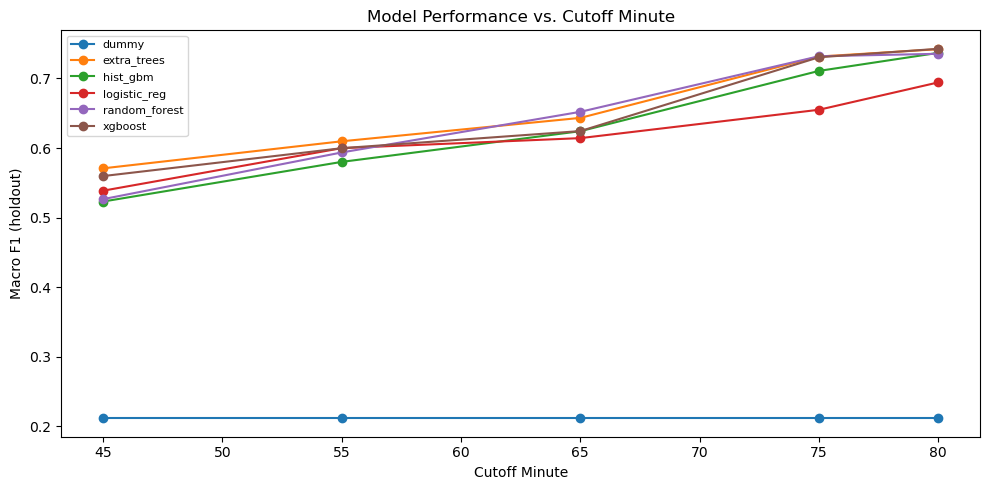

Saved cutoff_model_macro_f1.png


In [11]:
# -- Summary table: best model per cutoff --
best_by_cutoff = (
    results_df.sort_values(["cutoff", "macro_f1"], ascending=[True, False])
    .groupby("cutoff").first()
    .reset_index()[["cutoff", "model", "accuracy", "balanced_accuracy", "macro_f1", "weighted_f1"]]
)
best_by_cutoff.to_csv(OUTPUT_DIR / "tables" / "best_model_by_cutoff.csv", index=False)
print("Best model at each cutoff:")
display(best_by_cutoff.round(3))

# We present 75 min as our chosen cutoff — it's only marginally behind 80 min
# but is more realistic for live in-game prediction (15 min still left to play)
print("\n>> Chosen cutoff for final presentation: 75 minutes")
chosen_row = best_by_cutoff[best_by_cutoff["cutoff"] == 75.0].iloc[0]
print(f"   Model: {chosen_row['model']}  |  Accuracy: {chosen_row['accuracy']:.3f}  |  Macro F1: {chosen_row['macro_f1']:.3f}")

# Also show the full comparison table (all cutoffs, all models)
print("\nFull comparison table:")
display(results_df.sort_values(["cutoff", "macro_f1"], ascending=[True, False]).round(3).reset_index(drop=True))

# -- Line plot: macro F1 vs cutoff minute --
plt.figure(figsize=(10, 5))
for model_name, grp in results_df.groupby("model"):
    grp_sorted = grp.sort_values("cutoff")
    plt.plot(grp_sorted["cutoff"], grp_sorted["macro_f1"], marker="o", label=model_name)
plt.xlabel("Cutoff Minute")
plt.ylabel("Macro F1 (holdout)")
plt.title("Model Performance vs. Cutoff Minute")
plt.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figures" / "cutoff_model_macro_f1.png", dpi=150)
plt.show()
print("Saved cutoff_model_macro_f1.png")

## 11. Best Model Deep-Dive
We present the **75-minute cutoff** as our chosen model. While 80 minutes gives slightly higher accuracy, predicting with 15 minutes still to play is more meaningful and practical. Here we look at the confusion matrix, per-class performance, and the most important features.

Presented model: random_forest at cutoff 75 min
  Accuracy=0.751, Balanced acc=0.737, Macro F1=0.732

Confusion Matrix:


,away_win,draw,home_win
away_win,86,15,7
draw,19,55,13
home_win,3,34,133


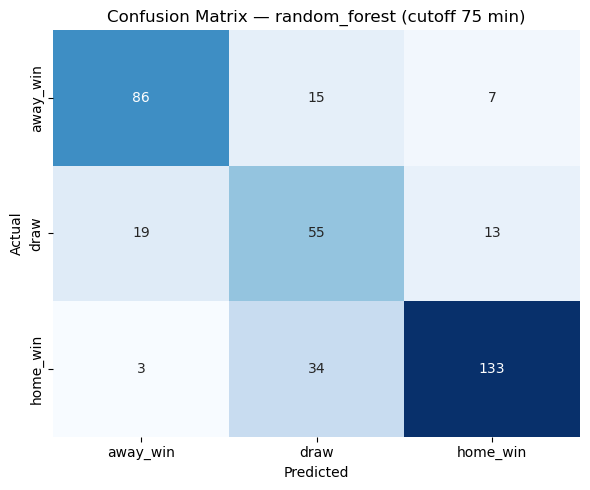


Classification Report:
              precision    recall  f1-score   support

    away_win       0.80      0.80      0.80       108
        draw       0.53      0.63      0.58        87
    home_win       0.87      0.78      0.82       170

    accuracy                           0.75       365
   macro avg       0.73      0.74      0.73       365
weighted avg       0.77      0.75      0.76       365



,precision,recall,f1-score,support
away_win,0.796,0.796,0.796,108.000
draw,0.529,0.632,0.576,87.000
home_win,0.869,0.782,0.824,170.000
accuracy,0.751,0.751,0.751,0.751
macro avg,0.731,0.737,0.732,365.000
weighted avg,0.767,0.751,0.756,365.000


In [12]:
# Pin the presented results to the 75-minute cutoff XGBoost (our chosen model)
PRESENTED_CUTOFF = 75.0
cutoff_75_results = results_df[results_df["cutoff"] == PRESENTED_CUTOFF].sort_values("macro_f1", ascending=False)
best_row  = cutoff_75_results.iloc[0]
best_name = best_row["model"]
print(f"Presented model: {best_name} at cutoff {PRESENTED_CUTOFF:g} min")
print(f"  Accuracy={best_row['accuracy']:.3f}, Balanced acc={best_row['balanced_accuracy']:.3f}, Macro F1={best_row['macro_f1']:.3f}")

best_pipe, _ = fitted_at_best[best_name]
y_pred = best_pipe.predict(best_X_test)

# -- Confusion matrix --
labels = ["away_win", "draw", "home_win"]
cm = confusion_matrix(best_y_test, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)
cm_df.to_csv(OUTPUT_DIR / "tables" / "confusion_matrix_best_model.csv")
print("\nConfusion Matrix:")
display(cm_df)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title(f"Confusion Matrix — {best_name} (cutoff {int(PRESENTED_CUTOFF)} min)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figures" / "best_model_confusion_matrix.png", dpi=150)
plt.show()

# -- Classification report --
print("\nClassification Report:")
print(classification_report(best_y_test, y_pred))
report_df = pd.DataFrame(classification_report(best_y_test, y_pred, output_dict=True)).T
report_df.to_csv(OUTPUT_DIR / "tables" / "classification_report_best_model.csv")
display(report_df.round(3))


Computing permutation importance for 'random_forest' (5 repeats)...

Top 10 most important features:


,feature,importance_mean,importance_std
0,is_draw_at_cutoff,0.0105,0.0044
1,abs_goal_diff,0.0102,0.0037
2,away_leading,0.0094,0.0024
3,away_goal_conversion,0.0089,0.0045
4,diff_prior_gd_per_game,0.0067,0.0043
5,away_crosses,0.0063,0.0015
6,away_counter_attacks,0.0055,0.0023
7,diff_duels_won,0.0048,0.0034
8,diff_goals,0.0048,0.0053
9,diff_duels_lost,0.0048,0.0013


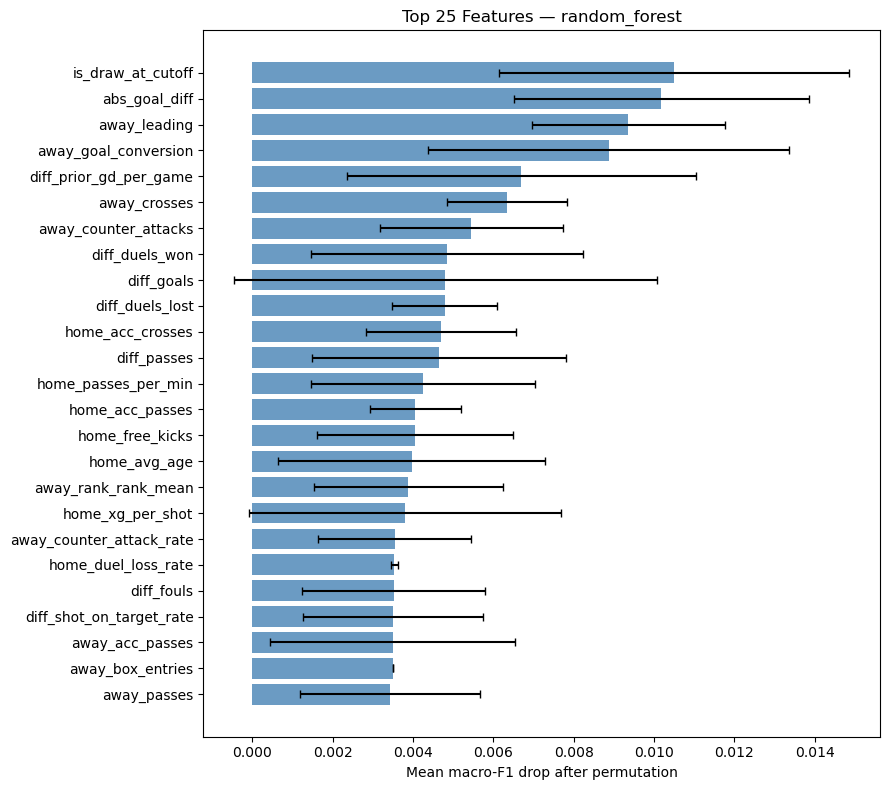

In [13]:
# -- Permutation feature importance --
# Only works for sklearn Pipeline objects (not the XGBWrapped)
# If the best model is XGBoost, fall back to the best sklearn model

importance_model_name = best_name
importance_pipe, _ = fitted_at_best.get(importance_model_name, (None, None))

if importance_pipe is None or not isinstance(importance_pipe, Pipeline):
    # Fall back to hist_gbm or random_forest
    for fallback in ["hist_gbm", "random_forest", "extra_trees"]:
        if fallback in fitted_at_best:
            importance_model_name = fallback
            importance_pipe, _ = fitted_at_best[fallback]
            break

if importance_pipe is not None and isinstance(importance_pipe, Pipeline):
    print(f"Computing permutation importance for '{importance_model_name}' ({PERMUTATION_REPEATS} repeats)...")
    perm = permutation_importance(
        importance_pipe, best_X_test, best_y_test,
        scoring="f1_macro", n_repeats=PERMUTATION_REPEATS,
        random_state=RANDOM_STATE, n_jobs=-1
    )
    imp_df = (
        pd.DataFrame({"feature": best_feature_cols,
                      "importance_mean": perm.importances_mean,
                      "importance_std":  perm.importances_std})
        .sort_values("importance_mean", ascending=False)
        .reset_index(drop=True)
    )
    imp_df.to_csv(OUTPUT_DIR / "tables" / "permutation_importance.csv", index=False)

    print("\nTop 10 most important features:")
    display(imp_df.head(10).round(4))

    top25 = imp_df.head(25).iloc[::-1]
    fig, ax = plt.subplots(figsize=(9, 8))
    ax.barh(top25["feature"], top25["importance_mean"], xerr=top25["importance_std"],
            color="steelblue", alpha=0.8, capsize=3)
    ax.set_xlabel("Mean macro-F1 drop after permutation")
    ax.set_title(f"Top 25 Features — {importance_model_name}")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "figures" / "permutation_feature_importance.png", dpi=150)
    plt.show()
else:
    print("Permutation importance skipped (no sklearn Pipeline found).")

## 12. Save the Best Model

In [14]:
# Save the best model so we can load it later without retraining
model_path = OUTPUT_DIR / "models" / "best_football_result_model.joblib"
joblib.dump(best_pipe, model_path)
print(f"Model saved to: {model_path}")

# Save a short summary of the whole run
summary = {
    "competitions_used": sorted(COMPETITIONS),
    "cutoff_minutes_tested": CUTOFF_MINUTES,
    "presented_cutoff": 75.0,
    "best_model": best_name,
    "accuracy":          round(float(best_row["accuracy"]), 4),
    "balanced_accuracy": round(float(best_row["balanced_accuracy"]), 4),
    "macro_f1":          round(float(best_row["macro_f1"]), 4),
    "weighted_f1":       round(float(best_row["weighted_f1"]), 4),
    "note": "75-min cutoff chosen for presentation. World Cup and European Championship excluded."
}
with (OUTPUT_DIR / "tables" / "run_summary.json").open("w") as f:
    json.dump(summary, f, indent=2)

print("\n=== Final Results ===")
for k, v in summary.items():
    print(f"  {k}: {v}")

Model saved to: artifacts/models/best_football_result_model.joblib

=== Final Results ===
  competitions_used: ['England', 'France', 'Germany', 'Italy', 'Spain']
  cutoff_minutes_tested: [45.0, 55.0, 65.0, 75.0, 80.0]
  presented_cutoff: 75.0
  best_model: random_forest
  accuracy: 0.7507
  balanced_accuracy: 0.7369
  macro_f1: 0.7319
  weighted_f1: 0.7565
  note: 75-min cutoff chosen for presentation. World Cup and European Championship excluded.
